# Setup and Final Evaluation

In [1]:
from keras.saving import register_keras_serializable
import tensorflow as tf
import keras
from tensorflow import data as tf_data
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras import layers
from sklearn.metrics import roc_curve, auc, recall_score

2025-07-30 14:52:37.810173: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-30 14:52:37.815550: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 14:52:37.859132: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-30 14:52:37.936299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753905158.021615    4820 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753905158.05

In [2]:
# Load in the DenseNet121 model
@register_keras_serializable(package="Custom")
def grayscale_to_rgb(x):
    return tf.image.grayscale_to_rgb(x)

dense = load_model("densenet.keras")

2025-07-30 14:52:42.798363: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
# Set the variables
image_size = (224, 224)
batch_size = 10
seed = 42

# Load in test set
test_ds = tf.keras.utils.image_dataset_from_directory(
    "test",
    image_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale", 
    seed=42,
    shuffle=False
)

test_augmentation = keras.Sequential([
    layers.Rescaling(1./255),])      

AUTOTUNE = tf.data.AUTOTUNE

# Apply rescaling to test data
test_ds = test_ds.map(lambda x, y: (test_augmentation(x), y), num_parallel_calls=AUTOTUNE)

# Prefetch for performance
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 336 files belonging to 2 classes.


For the final evaluation:
- AUC Score: 0.58
- Recall: 0.54

Looking at the predicted vs actual counts, the DenseNet121 model overestimated the amount of malignant tumors, leading to it missing some benign tumors. This could explain the relatively low AUC score, which is two points lower than it was on the validation set. However, the recall has increased significantly from the best baseline validation recall at 0.3480. This overfitting will be discussed in further detail in the README.md file.

34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 634ms/step


2025-07-30 14:53:11.475971: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


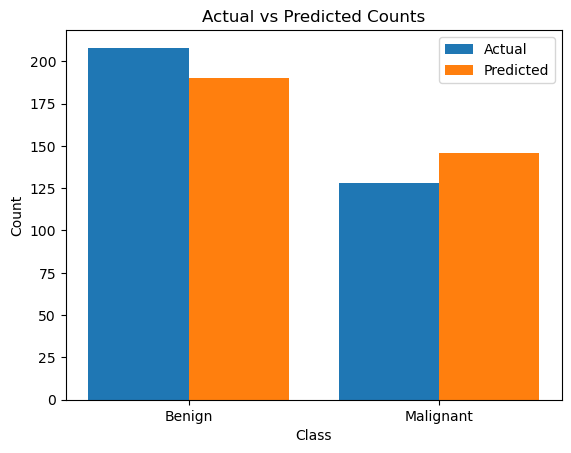

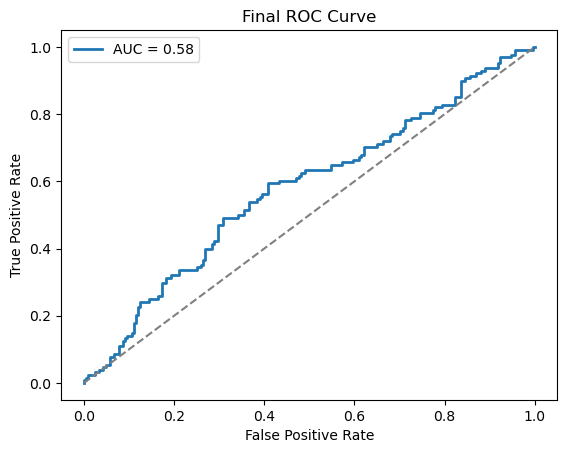

Recall: 0.54


In [4]:
y_pred_probs = dense.predict(test_ds).flatten()
y_true = np.concatenate([y for _, y in test_ds], axis=0)

class_names = ["Benign", "Malignant"]
y_pred = (y_pred_probs > 0.5).astype("int32")

num_classes = 2
actual_counts = [np.sum(y_true == i) for i in range(num_classes)]
predicted_counts = [np.sum(y_pred == i) for i in range(num_classes)]

# Create a plot of actual vs predicted cases
x = np.arange(num_classes)
plt.bar(x - 0.2, actual_counts, width=0.4, label='Actual')
plt.bar(x + 0.2, predicted_counts, width=0.4, label='Predicted')
plt.xticks(x, class_names) 
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Actual vs Predicted Counts')
plt.legend()
plt.show()

# Plot ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve")
plt.legend()
plt.show()

# Calculate final recall score
recall = recall_score(y_true, y_pred)
print(f"Recall: {recall:.2}")